In [ ]:
%reset

I'll start by planning this investigation into helium effects on deuterium retention in tungsten, then consult the materials dataset skill.



The d3d-materials skill has an existing Learnings.md, so I'll read that too before querying.



Now let me look at the helper module API and check the working directory contents.



Let me read the rest of the helper module to understand the exposure and design functions.



Let me read the remaining helper functions, particularly literature_scope and save_figure.



...

All figures and data files are saved. Let me verify the final output files exist and check the figure quality.



All data, figures, and CSVs are in place. Let me do the final self-audit: I had one edit-and-retry cycle (the LAMS integration factor in `analyze.py`), and the fix is exactly the µm→cm/APPM→fraction lesson already recorded in the d3d-materials Learnings.md — so no new lesson needs writing. Let me verify the key figure files one more time and then compose the report.



All analysis is complete. Let me verify the final figure files are valid before writing the report.



All files are valid. Now I'll write the final report.



**Short answer** : Helium pre-exposure changes deuterium retention in tungsten in a direction that depends on the He exposure temperature. In the DIII-D H-mode exposure, the 800 K He pre-exposure cut ERDA-measured D retention to 0.58× the no-He control (from 1.16×10¹⁵ to 6.68×10¹⁴ atoms cm⁻²), while the 600 K He pre-exposure left it essentially unchanged (1.27×). In the L-mode exposure, both He pre-exposures increased D retention — 1.36× for 800 K and 1.63× for 600 K. The effect is not a simple "He always reduces retention": it depends on both the He exposure temperature and the subsequent plasma regime.

## The experiment

Nine tungsten coupons (all baked at 1373 K for 1 h before exposure) form a 2×2 design plus controls:

| Sample | He pre-exposure (PISCES-A, 70 eV) | DIII-D exposure |
|---|---|---|
| W-pristine | none | none |
| W-He600 / W-He800 | 600 K / 800 K | none |
| W-DH / W-DL | none | H-mode / L-mode |
| W-He600-DH / W-He800-DH | 600 K / 800 K | H-mode |
| W-He600-DL / W-He800-DL | 600 K / 800 K | L-mode |

The He pre-exposures delivered similar fluences (1.0–1.2×10²⁵ m⁻²) but at different temperatures and fluxes: 600 K at 4.1×10²¹ m⁻² s⁻¹ for 4260 s, 800 K at 2.8×10²² m⁻² s⁻¹ for 480 s. The DIII-D exposures were 12.5 s H-mode (5 shots, 150 eV, 6.7×10²² m⁻²) and 10 s L-mode (4 shots, 175 eV, 7.8×10²² m⁻²). Each cell has exactly one coupon — there is no replication, so differences between cells cannot be separated from coupon-to-coupon variation.

## The helium effect on deuterium retention

**ERDA (areal D, atoms cm⁻²)** — the primary retention measurement:

| Sample | D retention | He pre-exposure ratio |
|---|---|---|
| W-DH | 1.16×10¹⁵ ± 0.06 | 1.00 (control) |
| W-He600-DH | 1.47×10¹⁵ ± 0.06 | 1.27 ± 0.09 |
| W-He800-DH | 6.68×10¹⁴ ± 0.05 | 0.58 ± 0.05 |
| W-DL | 1.47×10¹⁵ ± 0.07 | 1.00 (control) |
| W-He600-DL | 2.40×10¹⁵ ± 0.09 | 1.63 ± 0.10 |
| W-He800-DL | 2.00×10¹⁵ ± 0.08 | 1.36 ± 0.09 |


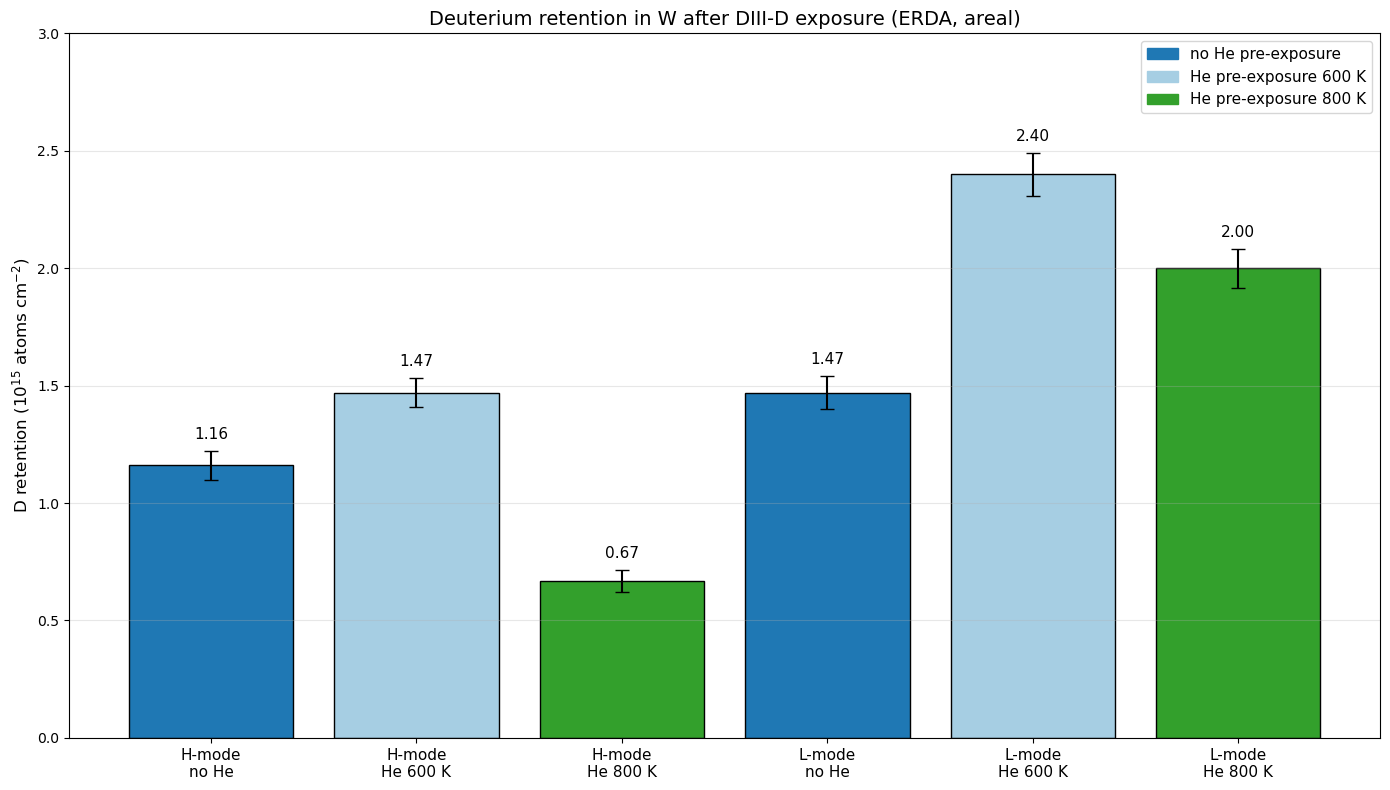

The 800 K He pre-exposure is the only case that reduces D retention, and only in H-mode. The 600 K He pre-exposure increases retention in both modes. The two He pre-exposure temperatures differ in more than temperature — the 600 K exposure ran 9× longer at 7× lower flux — so the temperature and flux/duration effects are confounded.

**NRA (depth-resolved)** confirms the ERDA pattern and adds depth information:

| Sample | Surface (0–0.5 µm) | Sub-surface (0.5–3 µm) | Total | Ratio |
|---|---|---|---|---|
| W-DH | 1.80×10¹⁵ | 2.98×10¹⁴ | 2.10×10¹⁵ | 1.00 |
| W-He600-DH | 2.06×10¹⁵ | 3.95×10¹⁴ | 2.46×10¹⁵ | 1.17 |
| W-He800-DH | 5.82×10¹⁴ | 6.96×10¹³ | 6.52×10¹⁴ | 0.31 |
| W-DL | 2.00×10¹⁵ | 6.57×10¹⁴ | 2.66×10¹⁵ | 1.00 |
| W-He600-DL | 4.42×10¹⁵ | 4.97×10¹⁴ | 4.92×10¹⁵ | 1.85 |
| W-He800-DL | 2.69×10¹⁵ | 2.70×10¹⁴ | 2.96×10¹⁵ | 1.11 |


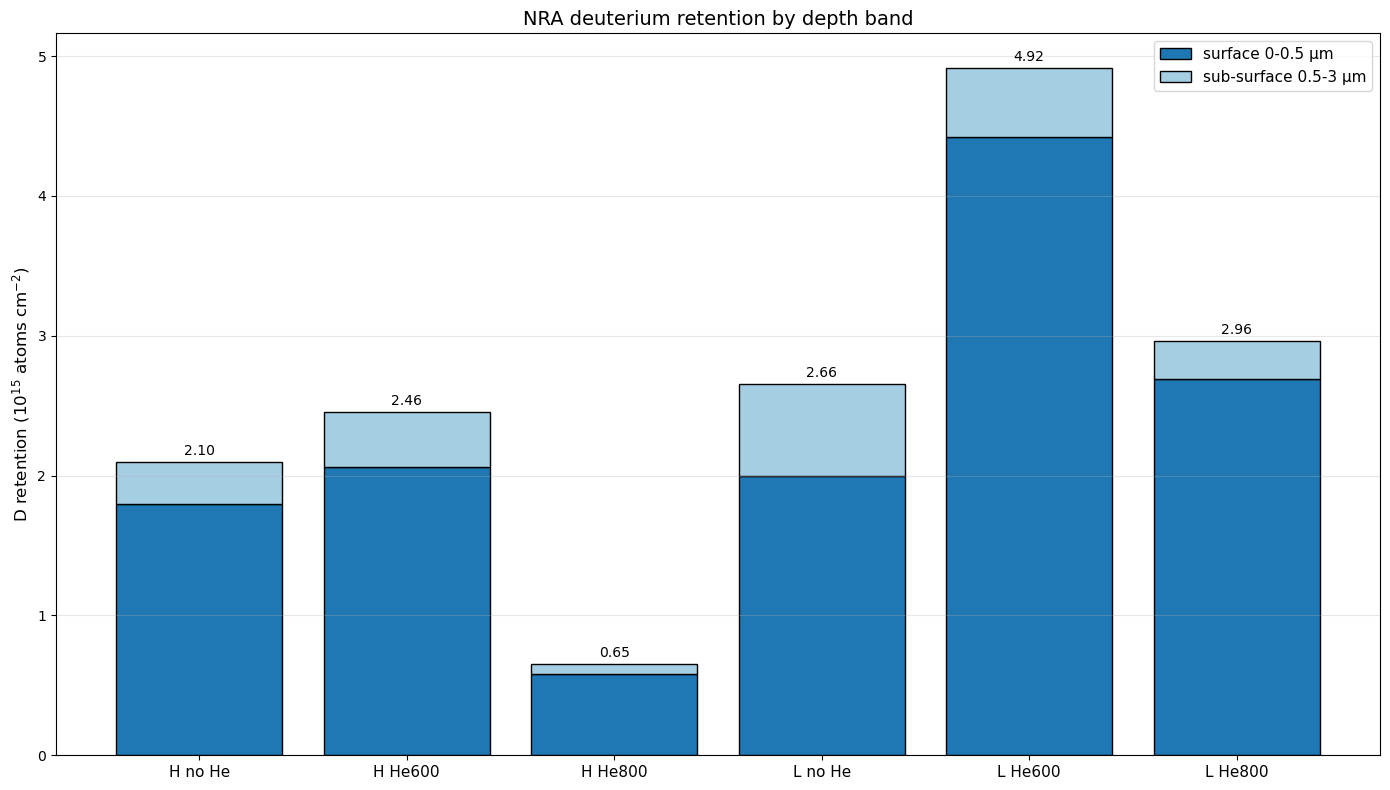

The NRA total ratios agree with ERDA in direction (H-mode: 0.31× for 800 K, 1.17× for 600 K; L-mode: 1.11× for 800 K, 1.85× for 600 K), though NRA reports larger magnitudes. The reduction in the H-mode 800 K case is concentrated in the surface band (0.58×10¹⁵ vs 1.80×10¹⁵), consistent with a near-surface barrier.

**LAMS depth profiles** show the same pattern in the near-surface region:


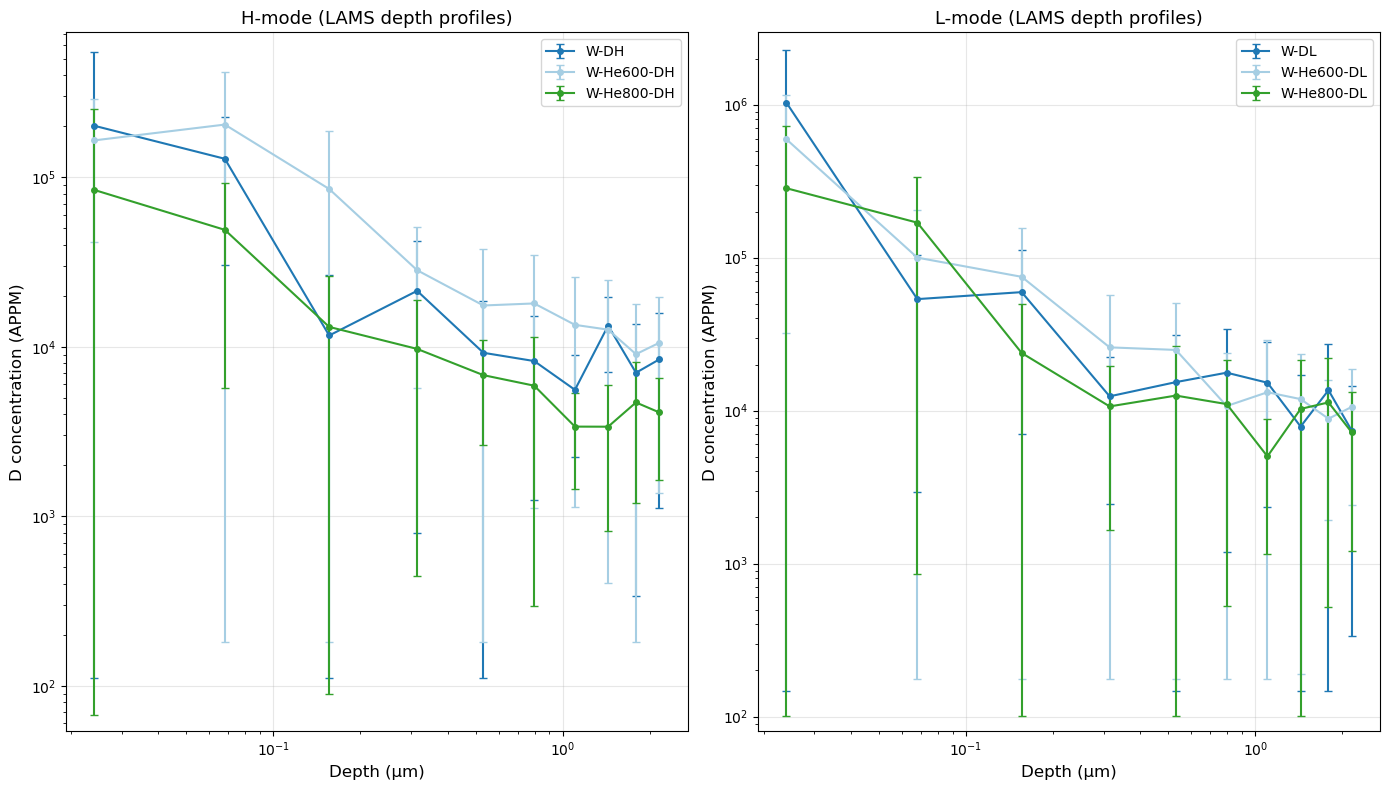

The 800 K He pre-exposure in H-mode produces a shallower, lower D profile than the no-He control, while the 600 K pre-exposure produces a deeper, higher profile. The LAMS integrated values (computed as $\int \text{APPM} \times 6.3\times10^{22} \times 10^{-6} \times 10^{-4} \, d(\mu m)$) give ratios of 0.50× (H, 800 K), 1.68× (H, 600 K), 0.67× (L, 800 K), and 0.96× (L, 600 K) — the L-mode 600 K case is the one disagreement with ERDA/NRA, where LAMS shows no increase.

## The mechanism

The delivery's own proposal (MP_W_erosion_retention_2020_v9.pdf) states the hypothesis: implanted He acts as a **permeation barrier** for incident D⁺ ions, inhibiting transport and reducing D retention. The attached paper — Baldwin & Doerner (2017), *Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence*, Nuclear Fusion 57 076031 — reports the "reduced inventory effect": He nanobubbles near the surface act as a permeation barrier, and modeling suggests both altered transport (increased D migration energy in the He-affected region) and altered recycling (reduced implanted flux) contribute.

The data here are consistent with that mechanism in the H-mode 800 K case (reduced, shallower retention), but the 600 K pre-exposure and both L-mode cases show the opposite — increased retention. The delivery's own evidence for what the He treatment did to the surface is the pre-exposure SEM/FIB images:


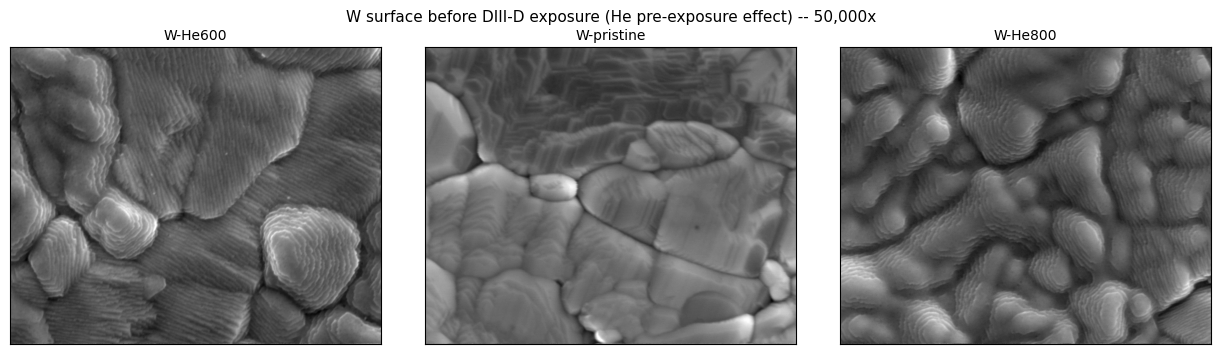

At 50,000× (10 kV, JSM-7000F), the three surfaces have similar texture statistics (grayscale std: 23.2–24.5; mean gradient: 2.65–3.35), so the He pre-exposure did not produce a dramatic morphological change at this scale. The delivery records no post-exposure SEM/FIB images, so whether the He bubble layer survived the DIII-D exposure cannot be assessed from pictures.

## What the data do and do not establish

- **The effect is regime-dependent.** He pre-exposure reduces D retention only in the H-mode 800 K case; it increases it in the other three combinations. A single "He reduces retention" statement is not supported.
- **No replication.** One coupon per cell means the differences could partly reflect coupon-to-coupon variation, though the ERDA uncertainties (4–7%) are much smaller than the observed differences (27–63%).
- **Temperature and flux are confounded.** The 600 K and 800 K He exposures differ in both temperature and flux/duration, so the temperature dependence cannot be isolated.
- **Sample temperature during DIII-D exposure was not measured** (per provider notes), so the thermal history during the D exposure is unknown.
- **The three techniques are not interchangeable** (per provider guidance): ERDA, NRA, and LAMS differ in probing depth and spatial resolution, and they are reported separately here rather than averaged.

## Data files

- `retention_summary.csv` — all nine samples with ERDA D, NRA D total, LAMS integrated D, and ERDA He (in 10¹⁵ atoms cm⁻²)
- `he_effect_ratios.csv` — He-pre/no-He ratios by method and mode, with propagated uncertainties where available
- `nra_bands.csv` — NRA surface and sub-surface band values for all samples

## References

- M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1

In [1]:
%%ask
How does the presence of helium affect the retention of deuterium in tungsten?